# Cluster Analysis (Hourly Electricity Load)
This notebook adapts the earlier train-only clustering workflow to parquet-backed versions of the `LD2011_2014` electricity panel.
It keeps the previous team's effective forecast split ratio (`8 weeks train : 7 days test`, i.e. `8:1`) for comparability, uses hourly resampling with `sum` for the clustering pipeline, computes clustering features from the train slice only, trims inactive train-period edges without `bfill`, and compares cluster counts before assigning meter clusters.


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

preprocess_dir = Path("data")
preprocess_dir.mkdir(parents=True, exist_ok=True)

out_dir = Path("data/clustering")
out_dir.mkdir(parents=True, exist_ok=True)

IMG_DIR = Path("images/clustering")
IMG_DIR.mkdir(parents=True, exist_ok=True)

def save_svg(filename):
    path = IMG_DIR / f"{filename}.svg"
    plt.savefig(path, format="svg", bbox_inches="tight")
    print("Saved:", path)


## One-time txt to parquet conversion

Run this once outside the notebook if the parquet inputs do not exist:

```python
from pathlib import Path
import pandas as pd

txt_path = Path("data/LD2011_2014.txt")
raw_parquet_path = Path("data/LD2011_2014.parquet")
hourly_parquet_path = Path("data/LD2011_2014_hourly_sum.parquet")

raw_15m = pd.read_csv(
    txt_path,
    sep=";",
    decimal=",",
    parse_dates=[0],
    index_col=0,
    low_memory=False,
)
raw_15m.index.name = "timestamp"
raw_15m.columns = raw_15m.columns.astype(str).str.replace('"', "", regex=False).str.strip()
raw_15m = raw_15m.apply(pd.to_numeric, errors="coerce").sort_index()

raw_15m.to_parquet(raw_parquet_path, index=True)
raw_15m.resample("h").sum(min_count=1).to_parquet(hourly_parquet_path, index=True)
print(raw_parquet_path)
print(hourly_parquet_path)
```

## Load data (wide 15-minute meter panel from parquet)


In [2]:
RAW_PARQUET_PATH = Path("data/LD2011_2014_15min.parquet")
HOURLY_PARQUET_PATH = Path("data/LD2011_2014_hourly_sum.parquet")

if not RAW_PARQUET_PATH.exists():
    raise FileNotFoundError(
        f"Missing {RAW_PARQUET_PATH}. Run the txt-to-parquet conversion snippet above first."
    )

raw_15m = pd.read_parquet(RAW_PARQUET_PATH).sort_index()
raw_15m.index = pd.to_datetime(raw_15m.index)
raw_15m.index.name = "timestamp"
raw_15m.columns = raw_15m.columns.astype(str)

print(f"Loaded raw parquet: {RAW_PARQUET_PATH}")
print(f"15-minute rows: {len(raw_15m):,}")
print(f"meter columns: {raw_15m.shape[1]:,}")
print(f"date range: {raw_15m.index.min()} -> {raw_15m.index.max()}")


Loaded raw parquet: data\LD2011_2014_15min.parquet
15-minute rows: 140,256
meter columns: 370
date range: 2011-01-01 00:15:00 -> 2015-01-01 00:00:00


## Resample to hourly load with `sum`, keep the previous team's 8:1 train:test split, and apply a light-touch activity filter (train only)


In [3]:
FORECAST_HORIZON_HOURS = 168
TRAIN_TO_TEST_RATIO = 8
TRAIN_WINDOW_HOURS = FORECAST_HORIZON_HOURS * TRAIN_TO_TEST_RATIO   # 1,344 hours = 8 weeks
MODEL_WINDOW_HOURS = TRAIN_WINDOW_HOURS + FORECAST_HORIZON_HOURS    # 1,512 hours = 9 weeks
MIN_ACTIVE_HOURS = 24 * 14        # light-touch filter: require at least 2 active weeks inside train
MIN_ACTIVE_RATIO = 0.05           # measured within the train-period active window only
MAX_FFILL_HOURS = 24              # causal fill only; no backward fill
LOAD_EPSILON = 1e-6
LOW_COVERAGE_THRESHOLD = 0.50
MEDIUM_COVERAGE_THRESHOLD = 0.80
HIGH_MISSING_THRESHOLD = 0.20
MEDIUM_MISSING_THRESHOLD = 0.05

# Use hourly sums for the clustering pipeline, as requested.
# min_count=1 preserves hours that are fully missing as NaN instead of forcing them to zero.
if HOURLY_PARQUET_PATH.exists():
    hourly_load = pd.read_parquet(HOURLY_PARQUET_PATH).sort_index()
    hourly_load.index = pd.to_datetime(hourly_load.index)
    hourly_load.index.name = "timestamp"
else:
    hourly_load = raw_15m.resample("h").sum(min_count=1)
hourly_load.index.name = "timestamp"

if len(hourly_load) <= MODEL_WINDOW_HOURS:
    raise ValueError(f"Not enough hourly rows for the required model window ({MODEL_WINDOW_HOURS} hours).")

model_window = hourly_load.iloc[-MODEL_WINDOW_HOURS:].copy()
train_hourly = model_window.iloc[:-FORECAST_HORIZON_HOURS].copy()
test_hourly = model_window.iloc[-FORECAST_HORIZON_HOURS:].copy()

activity_rows = []
for meter in train_hourly.columns:
    s = train_hourly[meter]
    active_mask = s.gt(LOAD_EPSILON)

    if not active_mask.any():
        activity_rows.append(
            {
                "meter_id": meter,
                "active_start": pd.NaT,
                "active_end": pd.NaT,
                "active_hours": 0,
                "coverage_ratio": 0.0,
                "positive_rate_in_active_window": 0.0,
                "internal_missing_rate_before_fill": 1.0,
                "std_load_in_active_window": 0.0,
                "keep_for_clustering": False,
            }
        )
        continue

    active_start = active_mask.idxmax()
    active_end = active_mask.iloc[::-1].idxmax()
    active_window = s.loc[active_start:active_end]
    active_hours = len(active_window)
    coverage_ratio = active_hours / TRAIN_WINDOW_HOURS
    positive_rate = active_window.gt(LOAD_EPSILON).mean()
    missing_rate = active_window.isna().mean()
    active_window_filled = active_window.ffill(limit=MAX_FFILL_HOURS).fillna(0.0)
    std_load = float(active_window_filled.std()) if active_hours > 1 else 0.0

    keep = (
        active_hours >= MIN_ACTIVE_HOURS
        and positive_rate >= MIN_ACTIVE_RATIO
        and std_load > 0
    )

    activity_rows.append(
        {
            "meter_id": meter,
            "active_start": active_start,
            "active_end": active_end,
            "active_hours": active_hours,
            "coverage_ratio": coverage_ratio,
            "positive_rate_in_active_window": positive_rate,
            "internal_missing_rate_before_fill": missing_rate,
            "std_load_in_active_window": std_load,
            "keep_for_clustering": keep,
        }
    )

activity_df = pd.DataFrame(activity_rows).set_index("meter_id").sort_index()

activity_df["reliability_flag"] = np.select(
    [
        ~activity_df["keep_for_clustering"],
        (activity_df["coverage_ratio"] < LOW_COVERAGE_THRESHOLD)
        | (activity_df["internal_missing_rate_before_fill"] > HIGH_MISSING_THRESHOLD),
        (activity_df["coverage_ratio"] < MEDIUM_COVERAGE_THRESHOLD)
        | (activity_df["internal_missing_rate_before_fill"] > MEDIUM_MISSING_THRESHOLD),
    ],
    [
        "exclude",
        "low",
        "medium",
    ],
    default="high",
)

activity_df["reliability_flag_code"] = activity_df["reliability_flag"].map(
    {"exclude": 0, "low": 1, "medium": 2, "high": 3}
)

keep_meters = activity_df.index[activity_df["keep_for_clustering"]].tolist()

print(f"Hourly rows (full): {len(hourly_load):,}")
print(f"Model window rows : {len(model_window):,} ({model_window.index.min()} -> {model_window.index.max()})")
print(f"Train hourly rows: {len(train_hourly):,} ({train_hourly.index.min()} -> {train_hourly.index.max()})")
print(f"Test hourly rows : {len(test_hourly):,} ({test_hourly.index.min()} -> {test_hourly.index.max()})")
print(f"Train:test ratio : {len(train_hourly) / len(test_hourly):.1f}:1")
print(f"Meters kept for clustering: {len(keep_meters):,} / {train_hourly.shape[1]:,}")
display(
    activity_df[
        [
            "active_hours",
            "coverage_ratio",
            "positive_rate_in_active_window",
            "internal_missing_rate_before_fill",
            "reliability_flag",
        ]
    ].head()
)


Hourly rows (full): 35,065
Model window rows : 1,512 (2014-10-30 01:00:00 -> 2015-01-01 00:00:00)
Train hourly rows: 1,344 (2014-10-30 01:00:00 -> 2014-12-25 00:00:00)
Test hourly rows : 168 (2014-12-25 01:00:00 -> 2015-01-01 00:00:00)
Train:test ratio : 8.0:1
Meters kept for clustering: 369 / 370


,active_hours,coverage_ratio,positive_rate_in_active_window,internal_missing_rate_before_fill,reliability_flag
meter_id,,,,,
MT_001,1344,1.0,0.998512,0.0,high
MT_002,1344,1.0,1.000000,0.0,high
MT_003,1344,1.0,0.988095,0.0,high
MT_004,1344,1.0,1.000000,0.0,high
MT_005,1344,1.0,1.000000,0.0,high


Saved: images\clustering\meter_activity_cutoff.svg


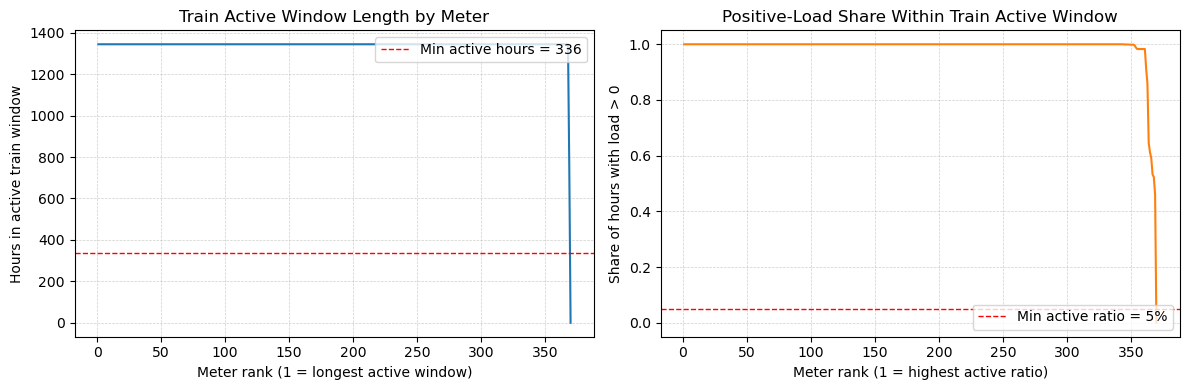

In [ ]:
rank = np.arange(1, len(activity_df) + 1)
active_sorted = activity_df["active_hours"].sort_values(ascending=False).values
rate_sorted = activity_df["positive_rate_in_active_window"].sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rank, active_sorted, color="tab:blue")
axes[0].axhline(
    MIN_ACTIVE_HOURS,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Min active hours = {MIN_ACTIVE_HOURS}",
)
axes[0].set_title("Train Active Window Length by Meter")
axes[0].set_xlabel("Meter rank (1 = longest active window)")
axes[0].set_ylabel("Hours in active train window")
axes[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
axes[0].legend(loc="lower left")

axes[1].plot(rank, rate_sorted, color="tab:orange")
axes[1].axhline(
    MIN_ACTIVE_RATIO,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Min active ratio = {MIN_ACTIVE_RATIO:.0%}",
)
axes[1].set_title("Positive-Load Share Within Train Active Window")
axes[1].set_xlabel("Meter rank (1 = highest active ratio)")
axes[1].set_ylabel("Share of hours with load > 0")
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
axes[1].legend(loc="lower left")

plt.tight_layout()
save_svg("meter_activity_cutoff")
plt.show()


## Save filtered train/test hourly loads and prepare train-only meter series for feature extraction


In [5]:
train_hourly = train_hourly[keep_meters].copy()
test_hourly = test_hourly[keep_meters].copy()

activity_df.to_parquet(preprocess_dir / "meter_activity_summary.parquet", index=True)
train_hourly.to_parquet(preprocess_dir / "train_hourly_preprocessed.parquet", index=True)
test_hourly.to_parquet(preprocess_dir / "test_hourly_preprocessed.parquet", index=True)

feature_ready_series = {}
for meter in keep_meters:
    active_start = activity_df.loc[meter, "active_start"]
    active_end = activity_df.loc[meter, "active_end"]
    s = train_hourly.loc[active_start:active_end, meter].copy()
    s = s.ffill(limit=MAX_FFILL_HOURS).fillna(0.0)
    feature_ready_series[meter] = s

print("Saved preprocessing-only train/test hourly loads and meter activity summary under data/")
print(f"Prepared {len(feature_ready_series):,} train-only meter series for feature extraction.")


Saved preprocessing-only train/test hourly loads and meter activity summary under data/
Prepared 369 train-only meter series for feature extraction.


## Feature helpers (hourly load seasonality / stability / intermittency)

- **Level / scale**: mean, median, and 95th-percentile hourly load plus load factor.
- **Volatility / stability**: coefficient of variation, rolling variability, and ramp volatility.
- **Seasonality**: ACF/PACF at hourly and daily lags, daily and weekly STL strength, FFT dominant period, and spectral entropy.
- **Irregularity**: active-rate, average positive-load gap, longest zero streak, ADI, and CV2.
- **Load shape**: night-to-day ratio and weekend-to-weekday ratio.
- **Trend / stationarity**: rolling weekly slope, net growth, ADF p-value, and KPSS p-value.
- **Coverage / reliability**: active training hours, coverage ratio, internal missing rate before filling, and a downstream reliability flag.

**How meters with different sequence lengths can still be clustered together**
- The clustering model does **not** use raw hourly series directly. Each meter is converted into one fixed-length feature vector.
- The features are computed on that meter's **train-period active window**, so meters can have different raw durations but still map into the same feature space.
- To make length and data quality explicit instead of hidden, the feature table also includes `active_hours`, `coverage_ratio`, and `internal_missing_rate_before_fill`.

**Why missingness can still matter for later user-level prediction**
- If two users are assigned to the same cluster but one user has much lower coverage, that user's feature estimates are less stable and the cluster assignment is less reliable.
- That does not invalidate cluster-level forecasting, but it does mean user-level forecast confidence should not be treated as uniform.
- The notebook therefore creates a `reliability_flag` so later prediction code can explicitly mark low-quality users before returning user-level outputs.

**Why `ffill` is reasonable here**
- The target is electricity load, a continuous state variable with strong short-horizon persistence; if a reading is briefly missing, the most recent observed load is usually a better causal proxy than a future value.
- `ffill` respects time direction. It uses only information already available at that timestamp, so it does not leak future information into clustering or model evaluation.
- A capped `ffill(limit=24)` is intentionally conservative: it covers short telemetry gaps but avoids inventing long flat stretches across genuine outages or meter inactivity.

**Why not `bfill` or unrestricted interpolation**
- `bfill` is not appropriate for train-only feature generation because it injects future information into earlier timestamps.
- Long linear or spline interpolation is also hard to justify here because meter load can change sharply by hour and by time-of-day; smoothing across long gaps can fabricate behavior that never occurred.

**Most reasonable missing-data policy for this problem**
1. Trim obvious pre-activation or post-activity edges inside the train period.
2. Preserve genuine zero load as zero; do not automatically convert all zeros to missing.
3. Use short, capped forward fill for internal gaps.
4. Leave long gaps as missing during diagnostics and filtering, and drop meters only when they have too little active train history to support stable clustering.

All features are computed from the **training window only** after trimming each meter to its **train-period active window**. Missing values are handled with **forward fill only** inside that train window; there is **no backward fill**.


In [6]:
from statsmodels.tsa.stattools import adfuller, kpss, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning

MAX_PACF_LAG = 24
DAILY_PERIOD = 24
WEEKLY_PERIOD = 24 * 7
ROLLING_WINDOW = 24
TREND_WINDOW = 24 * 7

def longest_zero_streak(arr, eps=LOAD_EPSILON):
    max_run, run = 0, 0
    for v in arr:
        if np.isnan(v) or abs(v) <= eps:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

def safe_autocorr(s: pd.Series, lag: int) -> float:
    s = s.ffill().fillna(0.0)
    if len(s) <= lag:
        return np.nan
    if s.std() == 0:
        return 0.0
    return s.autocorr(lag=lag)

def safe_pacf_vals(s: pd.Series, max_lag: int):
    s = s.ffill().fillna(0.0)
    if len(s) <= max_lag + 1 or s.std() == 0:
        return [np.nan] * (max_lag + 1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            return pacf(s, nlags=max_lag, method="ywm")
        except Exception:
            return [np.nan] * (max_lag + 1)

def stl_seasonality_strength(x, period):
    try:
        if len(x) < 2 * period:
            return np.nan
        res = STL(x, period=period, robust=True).fit()
        var_resid = np.var(res.resid)
        var_total = np.var(res.resid + res.seasonal)
        if var_total == 0:
            return 0.0
        return 1 - (var_resid / var_total)
    except Exception:
        return np.nan

def fft_features(y):
    y = np.asarray(y, dtype=float)
    if len(y) < 2 * DAILY_PERIOD or np.allclose(y, y[0]):
        return np.nan, np.nan
    y = y - np.nanmean(y)
    freqs = np.fft.rfftfreq(len(y), d=1)
    power = np.abs(np.fft.rfft(y)) ** 2
    power[0] = 0
    if power.sum() == 0:
        return np.nan, np.nan
    dom_freq = freqs[np.argmax(power)]
    dom_period = 1.0 / dom_freq if dom_freq > 0 else np.nan
    p = power / power.sum()
    spectral_entropy = -np.sum(p * np.log(p + 1e-12)) / np.log(len(p))
    return dom_period, spectral_entropy

def stationarity_tests(y):
    if len(y) < 2 * DAILY_PERIOD or np.nanstd(y) == 0:
        return np.nan, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        try:
            adf_p = adfuller(y, maxlag=DAILY_PERIOD, autolag="AIC")[1]
        except Exception:
            adf_p = np.nan
        try:
            kpss_p = kpss(y, nlags="auto")[1]
        except Exception:
            kpss_p = np.nan
    return adf_p, kpss_p

def intermittency_features(y, eps=LOAD_EPSILON):
    idx = np.where(y > eps)[0]
    if len(idx) <= 1:
        adi = len(y)
        cv2 = np.nan
    else:
        adi = np.mean(np.diff(idx))
        demand = y[idx]
        m = demand.mean()
        cv2 = ((demand.std() / m) ** 2) if m > eps else np.nan
    return adi, cv2

def extract_features(s: pd.Series) -> dict:
    s = s.sort_index().astype(float)
    s = s.ffill(limit=MAX_FFILL_HOURS).fillna(0.0)
    y = s.to_numpy()
    n = len(y)

    active = y > LOAD_EPSILON
    nz_idx = np.where(active)[0]

    active_rate = active.mean()
    avg_gap = np.mean(np.diff(nz_idx)) if len(nz_idx) > 1 else n
    lz = longest_zero_streak(y)

    mean_y = float(np.mean(y))
    median_y = float(np.median(y))
    std_y = float(np.std(y))
    pos = y[active]
    p95 = float(np.percentile(pos, 95)) if len(pos) > 0 else 0.0
    load_factor = mean_y / p95 if p95 > 0 else 0.0
    cv = std_y / mean_y if mean_y > LOAD_EPSILON else 0.0

    roll = s.rolling(ROLLING_WINDOW, min_periods=max(6, ROLLING_WINDOW // 2))
    roll_ratio = (roll.std() / roll.mean()).replace([np.inf, -np.inf], np.nan).mean()
    ramp_volatility = float(np.mean(np.abs(np.diff(y)))) if n > 1 else 0.0

    trend_base = s.rolling(TREND_WINDOW, min_periods=DAILY_PERIOD).mean().dropna()
    if len(trend_base) > 1:
        slope = float(np.polyfit(np.arange(len(trend_base)), trend_base.values, 1)[0])
        net_growth = float(trend_base.iloc[-1] - trend_base.iloc[0])
    else:
        slope = 0.0
        net_growth = 0.0

    acf_1 = safe_autocorr(s, 1)
    acf_24 = safe_autocorr(s, 24)
    acf_168 = safe_autocorr(s, 168)
    pacf_vals = safe_pacf_vals(s, MAX_PACF_LAG)
    pacf_1 = pacf_vals[1] if len(pacf_vals) > 1 else np.nan
    pacf_24 = pacf_vals[24] if len(pacf_vals) > 24 else np.nan
    stl_daily = stl_seasonality_strength(s, DAILY_PERIOD)
    stl_weekly = stl_seasonality_strength(s, WEEKLY_PERIOD)

    dom_period, spectral_entropy = fft_features(y)
    adf_p, kpss_p = stationarity_tests(y)
    adi, cv2 = intermittency_features(y)

    night_mask = (s.index.hour >= 22) | (s.index.hour <= 6)
    day_mask = ~night_mask
    weekend_mask = s.index.dayofweek >= 5
    weekday_mask = ~weekend_mask

    day_mean = float(s[day_mask].mean()) if day_mask.any() else np.nan
    night_mean = float(s[night_mask].mean()) if night_mask.any() else np.nan
    weekday_mean = float(s[weekday_mask].mean()) if weekday_mask.any() else np.nan
    weekend_mean = float(s[weekend_mask].mean()) if weekend_mask.any() else np.nan

    night_ratio = night_mean / day_mean if pd.notna(day_mean) and day_mean > LOAD_EPSILON else np.nan
    weekend_ratio = weekend_mean / weekday_mean if pd.notna(weekday_mean) and weekday_mean > LOAD_EPSILON else np.nan

    return {
        "active_rate": active_rate,
        "avg_gap_hours": avg_gap,
        "longest_zero_streak_hours": lz,
        "mean_hourly_load": mean_y,
        "median_hourly_load": median_y,
        "p95_load": p95,
        "load_factor": load_factor,
        "cv": cv,
        "rolling_std_mean_ratio": roll_ratio,
        "ramp_volatility": ramp_volatility,
        "acf_1": acf_1,
        "acf_24": acf_24,
        "acf_168": acf_168,
        "pacf_1": pacf_1,
        "pacf_24": pacf_24,
        "stl_daily_strength": stl_daily,
        "stl_weekly_strength": stl_weekly,
        "dominant_period_hours": dom_period,
        "spectral_entropy": spectral_entropy,
        "adf_pvalue": adf_p,
        "kpss_pvalue": kpss_p,
        "adi": adi,
        "cv2": cv2,
        "night_ratio": night_ratio,
        "weekend_ratio": weekend_ratio,
        "trend_slope": slope,
        "net_growth": net_growth,
    }

rows = []
for i, (meter, s) in enumerate(feature_ready_series.items(), start=1):
    feats = extract_features(s)
    feats["meter_id"] = meter
    rows.append(feats)
    if i % 50 == 0:
        print("processed", i)

feat_df = pd.DataFrame(rows).set_index("meter_id").sort_index()

coverage_df = activity_df[
    [
        "active_hours",
        "coverage_ratio",
        "internal_missing_rate_before_fill",
        "reliability_flag",
        "reliability_flag_code",
    ]
].copy()
feat_df = feat_df.join(coverage_df, how="left")

feat_df = feat_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
feat_df.to_parquet(out_dir / "feature_table_extended.parquet", index=True)
print("Saved feature_table_extended.parquet")


processed 50
processed 100
processed 150
processed 200
processed 250
processed 300
processed 350
Saved feature_table_extended.parquet


## Standardize clustering inputs


In [7]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    c for c in feat_df.columns
    if not c.startswith("cluster_")
    and pd.api.types.is_numeric_dtype(feat_df[c])
]
X = feat_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, index=feat_df.index, columns=feature_cols)
X_scaled_df.to_parquet(out_dir / "feature_table_extended_scaled.parquet", index=True)
print("Saved feature_table_extended_scaled.parquet")


Saved feature_table_extended_scaled.parquet


## Model selection

Use the same workflow logic as before: compare K across KMeans inertia + silhouette and GMM BIC, then carry the recommended `K` forward instead of hard-coding it.


Saved k_selection_metrics.parquet
Recommended K for KMeans (best silhouette): 3
Recommended K for GMM (lowest BIC): 2
Saved: images\clustering\k_selection_metrics.svg


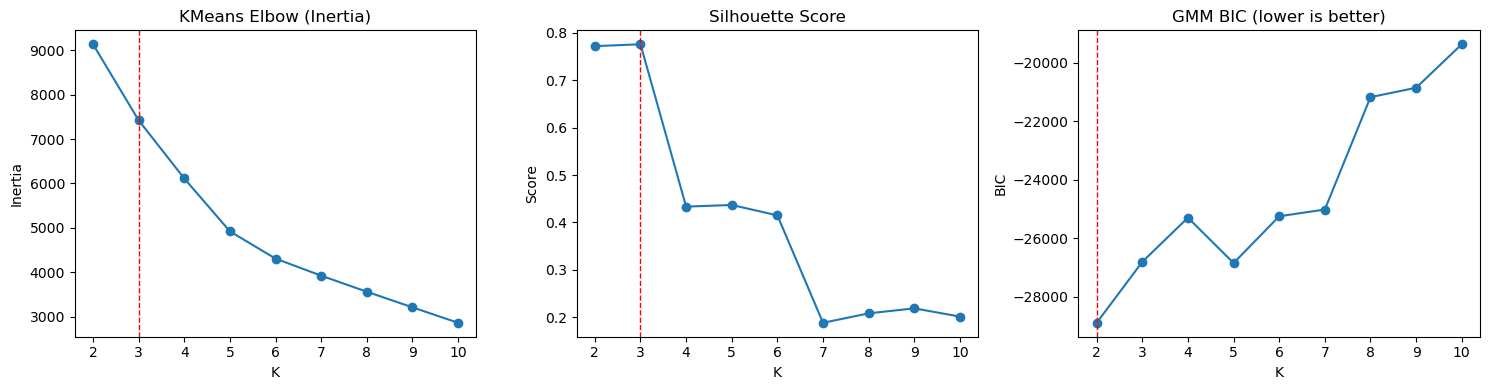

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

max_k = min(10, len(feat_df) - 1)
ks = range(2, max_k + 1)
inertias, sils, bics = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", random_state=123, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

    gmm = GaussianMixture(n_components=k, random_state=123)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

metrics_df = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": sils, "bic": bics})
recommended_kmeans_k = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
recommended_gmm_k = int(metrics_df.loc[metrics_df["bic"].idxmin(), "k"])
metrics_df["recommended_kmeans"] = metrics_df["k"].eq(recommended_kmeans_k)
metrics_df["recommended_gmm"] = metrics_df["k"].eq(recommended_gmm_k)

metrics_df.to_parquet(out_dir / "k_selection_metrics.parquet", index=False)
print("Saved k_selection_metrics.parquet")
print(f"Recommended K for KMeans (best silhouette): {recommended_kmeans_k}")
print(f"Recommended K for GMM (lowest BIC): {recommended_gmm_k}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o")
axes[0].axvline(recommended_kmeans_k, color="red", linestyle="--", linewidth=1)
axes[0].set_title("KMeans Elbow (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(metrics_df["k"], metrics_df["silhouette"], marker="o")
axes[1].axvline(recommended_kmeans_k, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

axes[2].plot(metrics_df["k"], metrics_df["bic"], marker="o")
axes[2].axvline(recommended_gmm_k, color="red", linestyle="--", linewidth=1)
axes[2].set_title("GMM BIC (lower is better)")
axes[2].set_xlabel("K")
axes[2].set_ylabel("BIC")

plt.tight_layout()
save_svg("k_selection_metrics")
plt.show()


## Fit clustering models


In [9]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

K_KMEANS = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
K_GMM = int(metrics_df.loc[metrics_df["bic"].idxmin(), "k"])

km = KMeans(n_clusters=K_KMEANS, init="k-means++", random_state=123, n_init=20)
feat_df["cluster_kmeans"] = km.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=K_GMM, random_state=123)
feat_df["cluster_gmm"] = gmm.fit_predict(X_scaled)

try:
    import hdbscan

    hdb = hdbscan.HDBSCAN(min_cluster_size=max(10, len(feat_df) // 20), min_samples=5)
    feat_df["cluster_hdbscan"] = hdb.fit_predict(X_scaled)
except Exception as e:
    print("HDBSCAN skipped:", e)
    feat_df["cluster_hdbscan"] = -1

label_cols = ["cluster_kmeans", "cluster_gmm", "cluster_hdbscan"]
feat_df[label_cols].to_parquet(out_dir / "clusters_3models.parquet", index=True)

size_df = pd.DataFrame(
    {
        "kmeans": feat_df["cluster_kmeans"].value_counts(normalize=True),
        "gmm": feat_df["cluster_gmm"].value_counts(normalize=True),
        "hdbscan": feat_df["cluster_hdbscan"].value_counts(normalize=True),
    }
).fillna(0).sort_index()

size_df.to_parquet(out_dir / "cluster_size_share_3models.parquet")
print(f"Using K_KMEANS={K_KMEANS} and K_GMM={K_GMM}")
display(size_df)


HDBSCAN skipped: No module named 'hdbscan'
Using K_KMEANS=3 and K_GMM=2


,kmeans,gmm,hdbscan
-1,0.00000,0.000000,1.0
0,0.98103,0.840108,0.0
1,0.00271,0.159892,0.0
2,0.01626,0.000000,0.0


Saved cluster_stability_ari_3models.parquet
Saved: images\clustering\cluster_stability_ari.svg


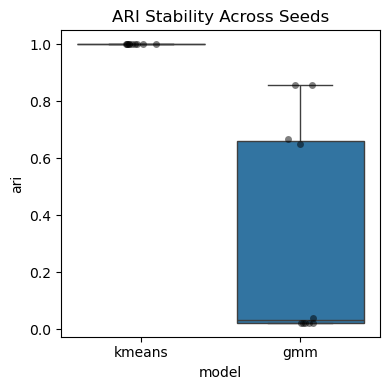

In [10]:
from sklearn.metrics import adjusted_rand_score
import seaborn as sns

ari_rows = []
for seed in range(10):
    km_seed = KMeans(n_clusters=K_KMEANS, init="k-means++", random_state=seed, n_init=100)
    gmm_seed = GaussianMixture(n_components=K_GMM, random_state=seed)
    ari_rows.append(
        {
            "seed": seed,
            "model": "kmeans",
            "ari": adjusted_rand_score(feat_df["cluster_kmeans"], km_seed.fit_predict(X_scaled)),
        }
    )
    ari_rows.append(
        {
            "seed": seed,
            "model": "gmm",
            "ari": adjusted_rand_score(feat_df["cluster_gmm"], gmm_seed.fit_predict(X_scaled)),
        }
    )

ari_df = pd.DataFrame(ari_rows)
ari_df.to_parquet(out_dir / "cluster_stability_ari_3models.parquet", index=False)
print("Saved cluster_stability_ari_3models.parquet")

plt.figure(figsize=(4, 4))
sns.boxplot(data=ari_df, x="model", y="ari")
sns.stripplot(data=ari_df, x="model", y="ari", color="black", alpha=0.5, jitter=0.1)
plt.title("ARI Stability Across Seeds")
plt.tight_layout()
save_svg("cluster_stability_ari")
plt.show()


## Cluster profiles


Saved: kmeans_k3_cluster_profiles_small.parquet
Saved: images\clustering\cluster_profiles.svg


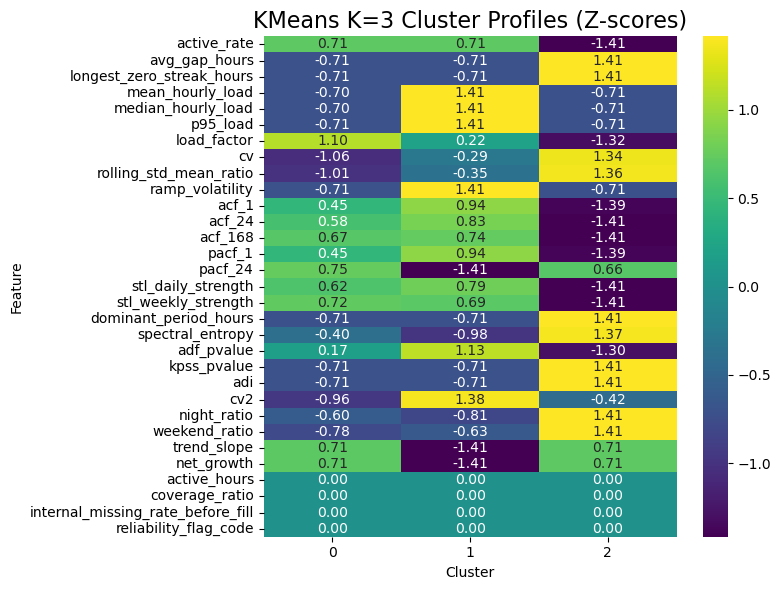

In [11]:
profile_cols = feature_cols.copy()

cluster_profiles = feat_df.groupby("cluster_kmeans")[profile_cols].median()
cluster_profiles["cluster_size"] = feat_df["cluster_kmeans"].value_counts().sort_index()

profile_tag = f"kmeans_k{K_KMEANS}"
cluster_profiles.to_parquet(out_dir / f"{profile_tag}_cluster_profiles_small.parquet")
print(f"Saved: {profile_tag}_cluster_profiles_small.parquet")

mean_profile = feat_df.groupby("cluster_kmeans")[profile_cols].mean()
median_profile = feat_df.groupby("cluster_kmeans")[profile_cols].median()
shift = mean_profile - median_profile
rel_shift = shift / median_profile.replace(0, np.nan)

mean_profile.to_csv(out_dir / f"{profile_tag}_profile_mean.csv")
median_profile.to_csv(out_dir / f"{profile_tag}_profile_median.csv")
shift.to_csv(out_dir / f"{profile_tag}_profile_mean_minus_median.csv")
rel_shift.to_csv(out_dir / f"{profile_tag}_profile_relative_shift.csv")

Z = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profiles[profile_cols]),
    index=cluster_profiles.index,
    columns=profile_cols,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Z.T, cmap="viridis", center=0, ax=ax, cbar=True, annot=True, fmt=".2f")
ax.set_title(f"KMeans K={K_KMEANS} Cluster Profiles (Z-scores)", fontsize=16)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")

plt.tight_layout()
save_svg("cluster_profiles")
plt.show()


## Optional visualization and summary


In [6]:
try:
    import umap
    from matplotlib.lines import Line2D

    cluster_counts = feat_df["cluster_kmeans"].value_counts().sort_index().to_dict()
    cluster_label_map = {
        int(cluster_id): f"Cluster {int(cluster_id)} (n={int(cluster_counts[cluster_id])})"
        for cluster_id in cluster_counts
    }

    emb = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1, random_state=123).fit_transform(X_scaled)
    plot_df = pd.DataFrame(emb, columns=["UMAP1", "UMAP2", "UMAP3"], index=feat_df.index)
    plot_df["cluster"] = feat_df["cluster_kmeans"].astype(int).values
    plot_df["cluster_label"] = plot_df["cluster"].map(cluster_label_map)
    hue_order = [cluster_label_map[int(cluster_id)] for cluster_id in sorted(cluster_label_map)]
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
    color_map = {
        cluster_label: colors[idx % len(colors)]
        for idx, cluster_label in enumerate(hue_order)
    }

    fig = plt.figure(figsize=(8.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_label in hue_order:
        cluster_slice = plot_df[plot_df["cluster_label"] == cluster_label]
        ax.scatter(
            cluster_slice["UMAP1"],
            cluster_slice["UMAP2"],
            cluster_slice["UMAP3"],
            s=32,
            alpha=0.82,
            color=color_map[cluster_label],
            label=cluster_label,
        )

    ax.set_title("UMAP 3D (KMeans clusters)")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_zlabel("UMAP3")
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", label=cluster_label, markerfacecolor=color_map[cluster_label], markersize=4)
        for cluster_label in hue_order
    ]
    ax.legend(handles=legend_handles, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    save_svg("umap_3d_clusters")
    plt.show()
except Exception as e:
    print("UMAP skipped:", e)


UMAP skipped: name 'feat_df' is not defined


In [7]:
labels = pd.read_parquet(out_dir / "clusters_3models.parquet")[["cluster_kmeans"]]
feat = pd.read_parquet(out_dir / "feature_table_extended.parquet")

# These are meter-level summary features, not cluster aggregate time-series targets.
# The names below are explicit to avoid confusing "mean of means" with a summed cluster load series.
cluster_stats = feat[["mean_hourly_load", "p95_load"]].join(labels).groupby("cluster_kmeans").agg(
    n_meters=("mean_hourly_load", "size"),
    sum_of_meter_mean_hourly_load=("mean_hourly_load", "sum"),
    avg_meter_mean_hourly_load=("mean_hourly_load", "mean"),
    median_meter_mean_hourly_load=("mean_hourly_load", "median"),
    avg_meter_p95_load=("p95_load", "mean"),
)
cluster_stats["meter_share"] = cluster_stats["n_meters"] / cluster_stats["n_meters"].sum()
cluster_stats["share_of_sum_of_meter_mean_hourly_load"] = (
    cluster_stats["sum_of_meter_mean_hourly_load"]
    / cluster_stats["sum_of_meter_mean_hourly_load"].sum()
)

display(cluster_stats.sort_values("sum_of_meter_mean_hourly_load", ascending=False))

largest_cluster = labels["cluster_kmeans"].value_counts().idxmax()
display(feat.join(labels).query("cluster_kmeans == @largest_cluster").head())


,n_meters,sum_of_meter_mean_hourly_load,avg_meter_mean_hourly_load,median_meter_mean_hourly_load,avg_meter_p95_load,meter_share,share_of_sum_of_meter_mean_hourly_load
cluster_kmeans,,,,,,,
0,362,667467.043537,1843.831612,507.466509,2569.198645,0.98103,0.825335
1,1,140427.455357,140427.455357,140427.455357,247885.000000,0.00271,0.173641
2,6,827.814324,137.969054,113.442573,415.492996,0.01626,0.001024


,active_rate,avg_gap_hours,longest_zero_streak_hours,mean_hourly_load,median_hourly_load,p95_load,load_factor,cv,rolling_std_mean_ratio,ramp_volatility,...,night_ratio,weekend_ratio,trend_slope,net_growth,active_hours,coverage_ratio,internal_missing_rate_before_fill,reliability_flag,reliability_flag_code,cluster_kmeans
meter_id,,,,,,,,,,,,,,,,,,,,,
MT_001,0.998512,1.001491,1,8.033448,8.883249,12.690355,0.633036,0.572383,0.386509,2.083562,...,1.189901,0.764273,0.001569,1.155729,1344,1.0,0.0,high,3,0
MT_002,1.000000,1.000000,0,92.569896,95.305832,115.931721,0.798486,0.174036,0.175593,5.877375,...,0.729475,1.002779,-0.003361,-8.606821,1344,1.0,0.0,high,3,0
MT_003,0.988095,1.012057,2,6.843170,6.950478,8.688097,0.787649,0.169073,0.146058,0.542117,...,0.965095,0.999736,-0.000004,-0.098258,1344,1.0,0.0,high,3,0
MT_004,1.000000,1.000000,0,526.592141,458.333333,908.231707,0.579799,0.340816,0.334138,63.450048,...,0.832017,1.077014,0.108347,153.491580,1344,1.0,0.0,high,3,0
MT_005,1.000000,1.000000,0,248.716064,234.146341,387.804878,0.641343,0.284337,0.247476,23.225215,...,0.967292,0.945140,0.084802,129.304588,1344,1.0,0.0,high,3,0


Saved: images\clustering\panel_distribution_time_series.svg


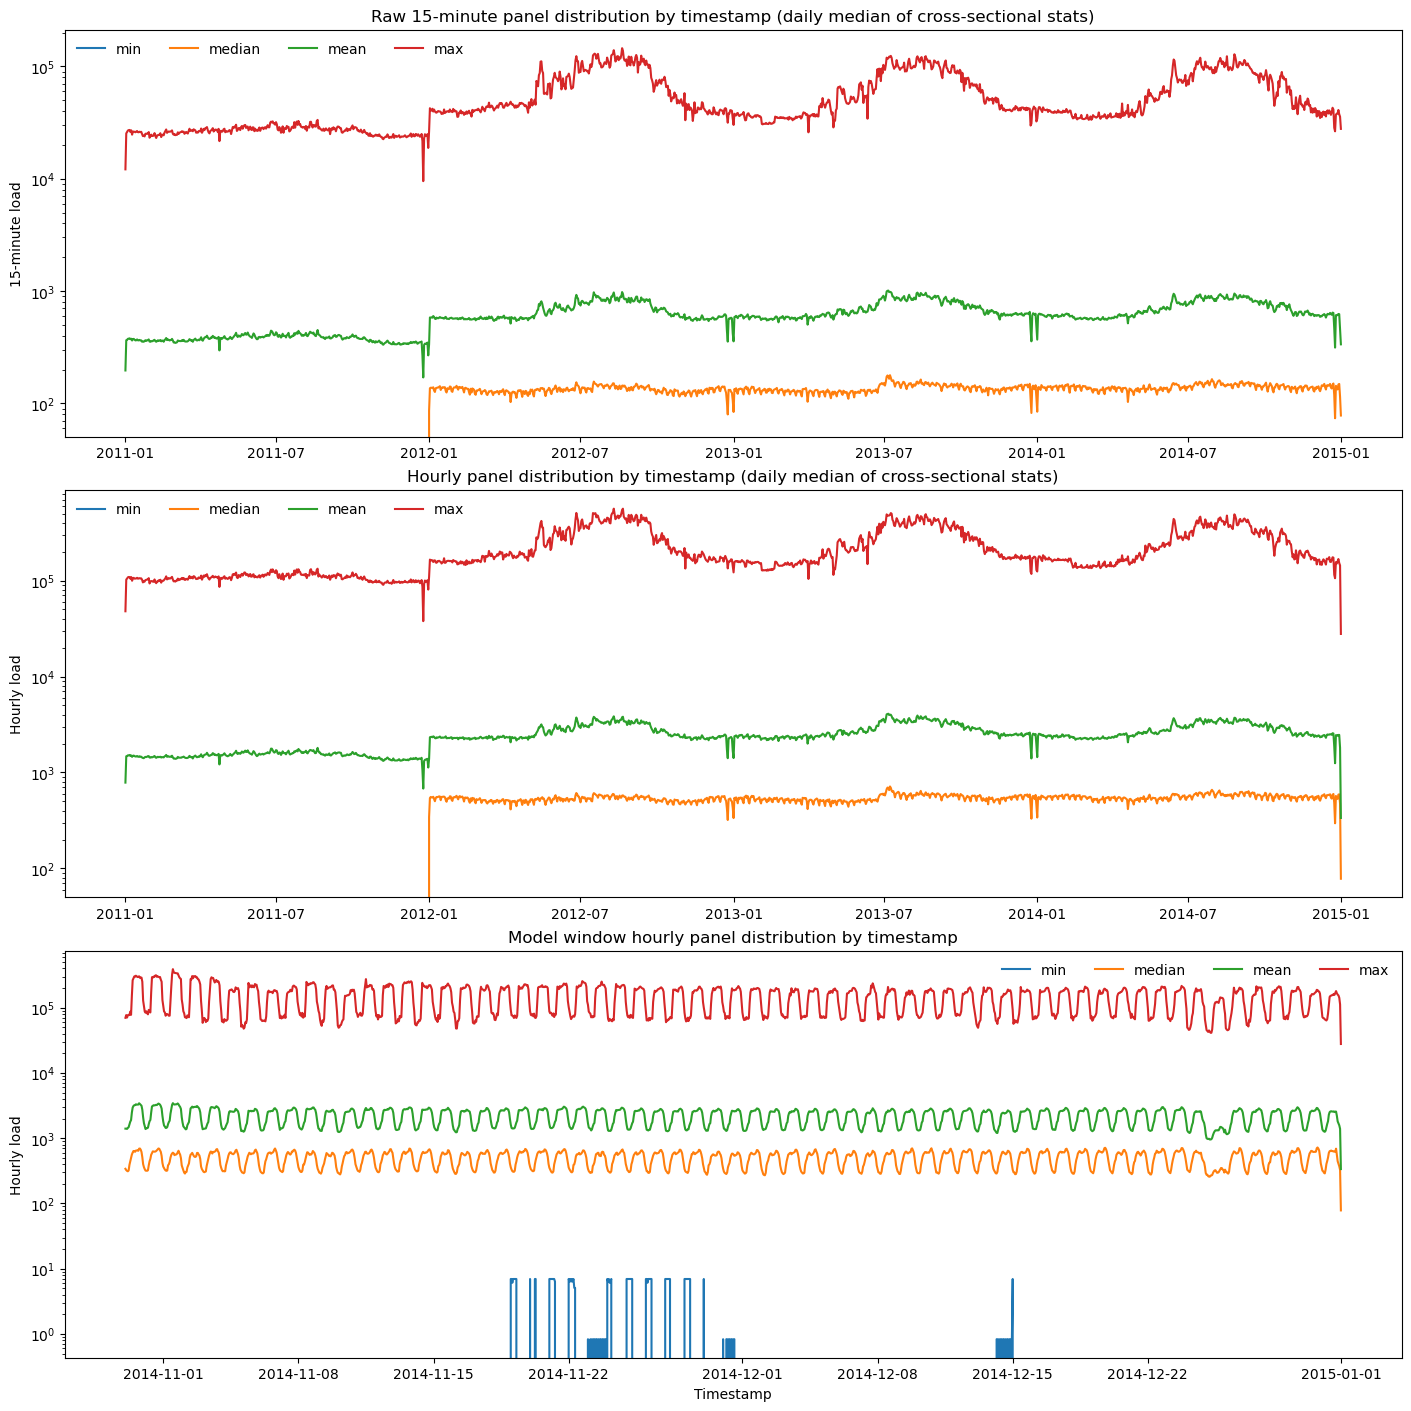

raw_15m_daily_cross_section                                          \
                               min      median         mean            max   
min                            0.0    0.000000   170.358961    9520.833333   
median                         0.0  131.249270   598.743068   40950.000000   
mean                           0.0  101.741772   606.335621   53296.776676   
max                            0.0  178.400749  1010.407106  145350.000000   

       hourly_daily_cross_section                                          \
                              min      median         mean            max   
min                           0.0    0.000000   335.714052   27800.000000   
median                        0.0  521.809311  2396.135340  170475.000000   
mean                          0.0  405.139620  2415.033223  214059.196876   
max                           0.0  714.748449  4096.517061  562350.000000   

       model_window_hourly_cross_section                           \
                                     min      median         mean   
min                             0.000000   78.236915   336.623846   
median                          0.000000  542.456814  2426.040004   
mean                            0.321145  492.264522  2168.755574   
max                             6.950478  721.300138  3445.640889   

                       
                  max  
min      27800.000000  
median  159250.000000  
mean    144618.466979  
max     390400.000000

In [9]:
panel_stat_cols = ["min", "median", "mean", "max"]

raw_parquet_candidates = [
    preprocess_dir / "LD2011_2014_15min.parquet",
    preprocess_dir / "LD2011_2014.parquet",
]
raw_parquet_path = next((path for path in raw_parquet_candidates if path.exists()), None)
if raw_parquet_path is None:
    raise FileNotFoundError("Missing raw 15-minute parquet file.")

raw_15m_local = pd.read_parquet(raw_parquet_path).sort_index()
raw_15m_local.index = pd.to_datetime(raw_15m_local.index)
hourly_load_local = pd.read_parquet(preprocess_dir / "LD2011_2014_hourly_sum.parquet").sort_index()
hourly_load_local.index = pd.to_datetime(hourly_load_local.index)
train_hourly_local = pd.read_parquet(preprocess_dir / "train_hourly_preprocessed.parquet").sort_index()
train_hourly_local.index = pd.to_datetime(train_hourly_local.index)
test_hourly_local = pd.read_parquet(preprocess_dir / "test_hourly_preprocessed.parquet").sort_index()
test_hourly_local.index = pd.to_datetime(test_hourly_local.index)
model_window_local = pd.concat([train_hourly_local, test_hourly_local]).sort_index()

raw_15m_panel_stats = raw_15m_local.agg(panel_stat_cols, axis=1).resample("D").median()
hourly_panel_stats = hourly_load_local.agg(panel_stat_cols, axis=1).resample("D").median()
model_window_panel_stats = model_window_local.agg(panel_stat_cols, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

for col in panel_stat_cols:
    axes[0].plot(raw_15m_panel_stats.index, raw_15m_panel_stats[col], label=col)
axes[0].set_title("Raw 15-minute panel distribution by timestamp (daily median of cross-sectional stats)")
axes[0].set_ylabel("15-minute load")
axes[0].set_yscale("log")
axes[0].legend(ncol=4, frameon=False)

for col in panel_stat_cols:
    axes[1].plot(hourly_panel_stats.index, hourly_panel_stats[col], label=col)
axes[1].set_title("Hourly panel distribution by timestamp (daily median of cross-sectional stats)")
axes[1].set_ylabel("Hourly load")
axes[1].set_yscale("log")
axes[1].legend(ncol=4, frameon=False)

for col in panel_stat_cols:
    axes[2].plot(model_window_panel_stats.index, model_window_panel_stats[col], label=col)
axes[2].set_title("Model window hourly panel distribution by timestamp")
axes[2].set_ylabel("Hourly load")
axes[2].set_xlabel("Timestamp")
axes[2].set_yscale("log")
axes[2].legend(ncol=4, frameon=False)

save_svg("panel_distribution_time_series")
plt.show()

panel_distribution_summary = pd.concat(
    {
        "raw_15m_daily_cross_section": raw_15m_panel_stats.agg(["min", "median", "mean", "max"]),
        "hourly_daily_cross_section": hourly_panel_stats.agg(["min", "median", "mean", "max"]),
        "model_window_hourly_cross_section": model_window_panel_stats.agg(["min", "median", "mean", "max"]),
    },
    axis=1,
)
display(panel_distribution_summary)



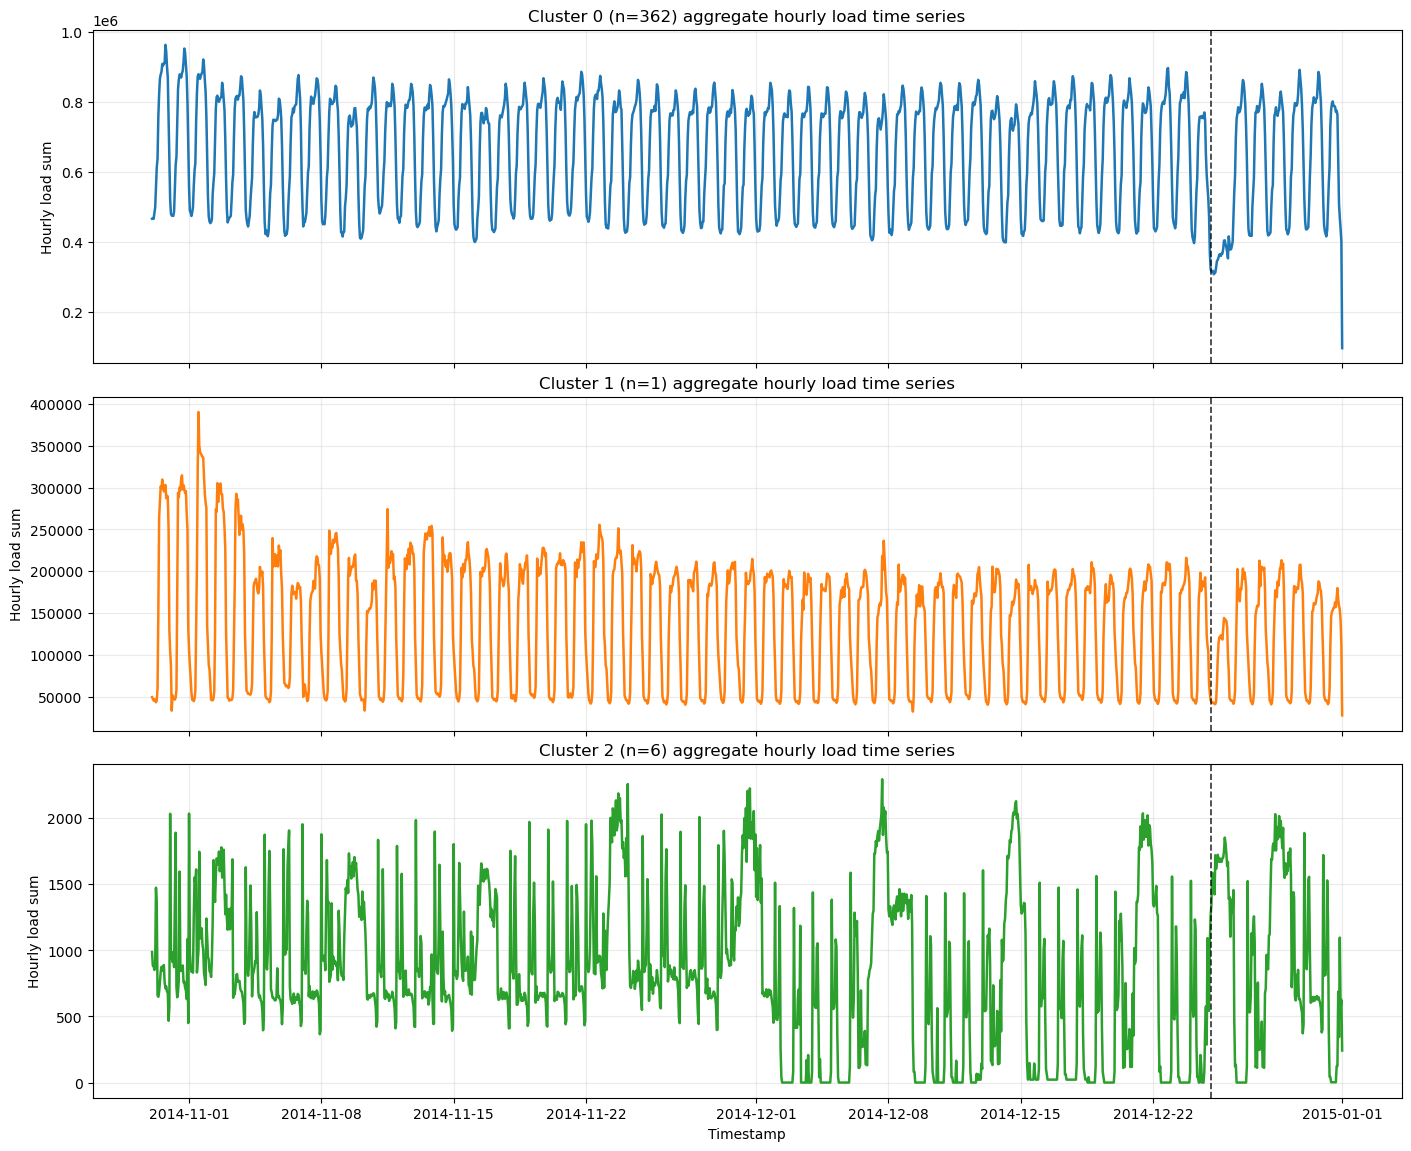

Saved: images\clustering\cluster_aggregate_distribution.svg


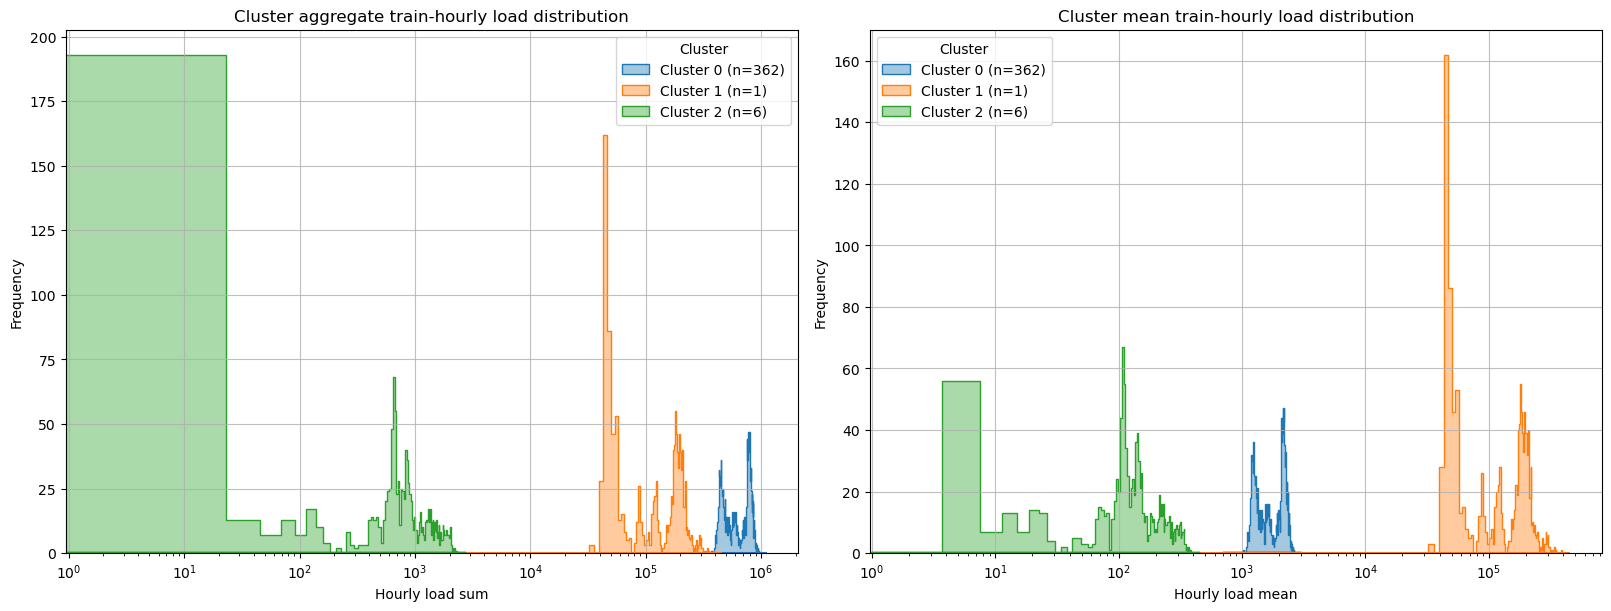

In [11]:
import seaborn as sns

labels_local = pd.read_parquet(out_dir / "clusters_3models.parquet")[["cluster_kmeans"]]
cluster_assignments = labels_local["cluster_kmeans"].sort_index().astype(int)
cluster_counts = cluster_assignments.value_counts().sort_index().to_dict()
cluster_label_map = {
    int(cluster_id): f"Cluster {int(cluster_id)} (n={int(cluster_counts[cluster_id])})"
    for cluster_id in cluster_counts
}
train_hourly_local = pd.read_parquet(preprocess_dir / "train_hourly_preprocessed.parquet").sort_index()
train_hourly_local.index = pd.to_datetime(train_hourly_local.index)
test_hourly_local = pd.read_parquet(preprocess_dir / "test_hourly_preprocessed.parquet").sort_index()
test_hourly_local.index = pd.to_datetime(test_hourly_local.index)
model_window_kept = pd.concat([train_hourly_local, test_hourly_local]).sort_index()

cluster_model_window = (
    model_window_kept.T
    .join(cluster_assignments.rename("cluster_kmeans"), how="inner")
    .groupby("cluster_kmeans")
    .sum(numeric_only=True)
    .T
    .sort_index(axis=1)
)
cluster_model_window.to_parquet(out_dir / "cluster_kmeans_model_window_aggregate.parquet", index=True)

cluster_train_aggregate = cluster_model_window.loc[train_hourly_local.index]
cluster_test_aggregate = cluster_model_window.loc[test_hourly_local.index]
cluster_train_aggregate.to_parquet(out_dir / "cluster_kmeans_train_aggregate.parquet", index=True)
cluster_test_aggregate.to_parquet(out_dir / "cluster_kmeans_test_aggregate.parquet", index=True)

cluster_ids = [int(cluster_id) for cluster_id in cluster_model_window.columns]
n_clusters = len(cluster_ids)
default_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
split_timestamp = test_hourly_local.index.min()

fig, axes = plt.subplots(n_clusters, 1, figsize=(14, 3.8 * n_clusters), sharex=True, constrained_layout=True)
if n_clusters == 1:
    axes = [axes]

for idx, (ax, cluster_id) in enumerate(zip(axes, cluster_ids)):
    color = default_colors[idx % len(default_colors)]
    cluster_name = cluster_label_map[cluster_id]
    ax.plot(cluster_model_window.index, cluster_model_window[cluster_id], color=color, linewidth=1.8)
    ax.axvline(split_timestamp, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(f"{cluster_name} aggregate hourly load time series")
    ax.set_ylabel("Hourly load sum")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Timestamp")
# save_svg("cluster_aggregate_time_series")
plt.show()

cluster_train_mean = (
    train_hourly_local.T
    .join(cluster_assignments.rename("cluster_kmeans"), how="inner")
    .groupby("cluster_kmeans")
    .mean(numeric_only=True)
    .T
    .sort_index(axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for idx, cluster_id in enumerate(cluster_ids):
    color = default_colors[idx % len(default_colors)]
    cluster_name = cluster_label_map[cluster_id]
    aggregate_values = cluster_train_aggregate[cluster_id].dropna()
    mean_values = cluster_train_mean[cluster_id].dropna()
    positive_mean_values = mean_values[mean_values > 0]

    sns.histplot(
        aggregate_values,
        bins=100,
        stat="count",
        element="step",
        fill=True,
        alpha=0.4,
        color=color,
        label=cluster_name,
        ax=axes[0],
    )
    sns.kdeplot(aggregate_values, color=color, linewidth=2.2, ax=axes[0])

    sns.histplot(
        positive_mean_values,
        bins=100,
        stat="count",
        element="step",
        fill=True,
        alpha=0.4,
        color=color,
        label=cluster_name,
        ax=axes[1],
    )
    sns.kdeplot(positive_mean_values, color=color, linewidth=2.2, ax=axes[1])

axes[0].set_title("Cluster aggregate train-hourly load distribution")
axes[0].set_xlabel("Hourly load sum")
axes[0].set_ylabel("Frequency")
axes[0].set_xscale("log")
axes[0].grid(alpha=0.8)
axes[0].legend(title="Cluster")

axes[1].set_title("Cluster mean train-hourly load distribution")
axes[1].set_xlabel("Hourly load mean")
axes[1].set_ylabel("Frequency")
axes[1].set_xscale("log")
axes[1].grid(alpha=0.8)
axes[1].legend(title="Cluster")
save_svg("cluster_aggregate_distribution")
plt.show()

Saved: images\clustering\eliminated_meter_preprocessing.svg


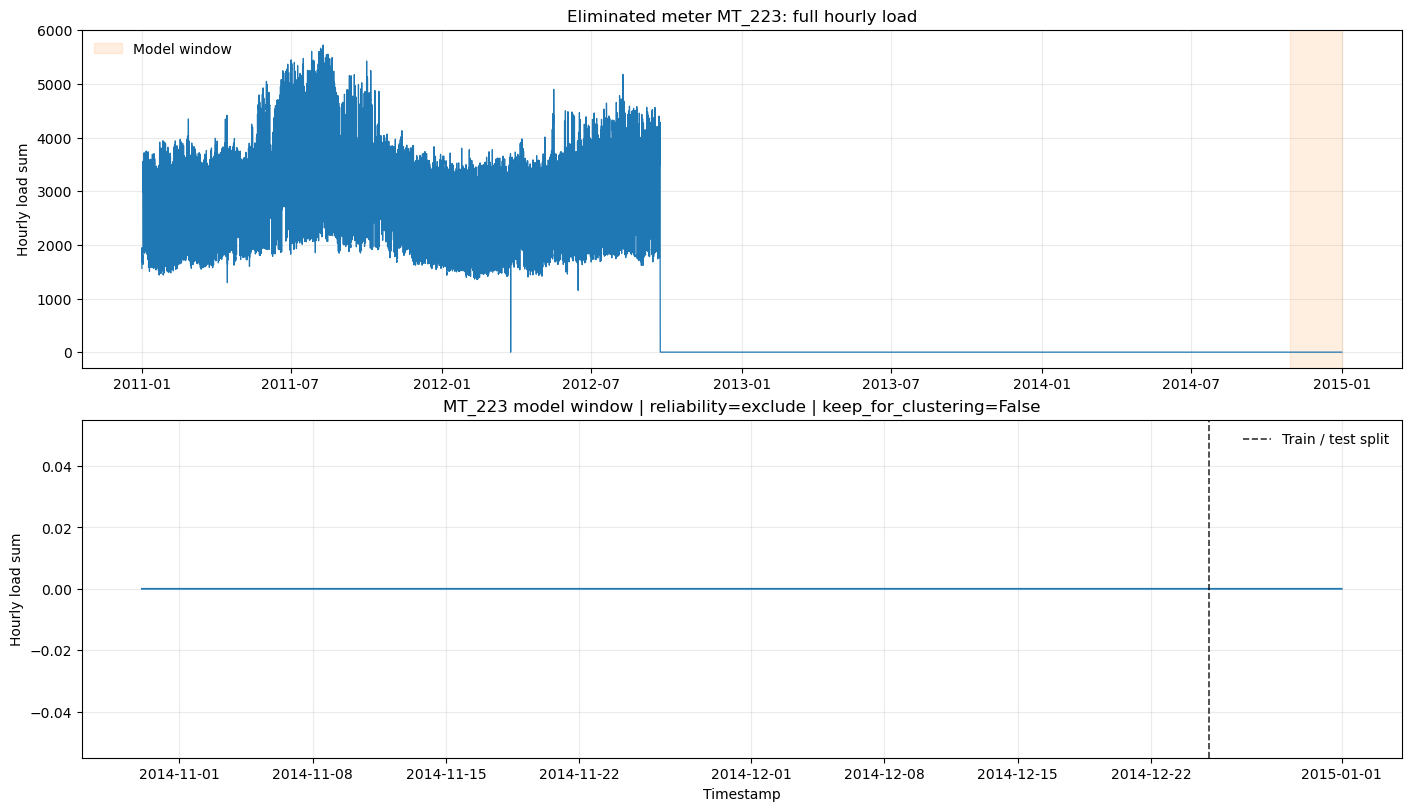

,value
active_hours,0
coverage_ratio,0.0
positive_rate_in_active_window,0.0
internal_missing_rate_before_fill,1.0
std_load_in_active_window,0.0
reliability_flag,exclude
keep_for_clustering,False


In [ ]:
activity_df_local = pd.read_parquet(preprocess_dir / "meter_activity_summary.parquet")
raw_parquet_candidates = [
    preprocess_dir / "LD2011_2014_15min.parquet",
    preprocess_dir / "LD2011_2014.parquet",
]
raw_parquet_path = next((path for path in raw_parquet_candidates if path.exists()), None)
if raw_parquet_path is None:
    raise FileNotFoundError("Missing raw 15-minute parquet file.")
hourly_load_local = pd.read_parquet(preprocess_dir / "LD2011_2014_hourly_sum.parquet").sort_index()
hourly_load_local.index = pd.to_datetime(hourly_load_local.index)
train_hourly_local = pd.read_parquet(preprocess_dir / "train_hourly_preprocessed.parquet").sort_index()
train_hourly_local.index = pd.to_datetime(train_hourly_local.index)
test_hourly_local = pd.read_parquet(preprocess_dir / "test_hourly_preprocessed.parquet").sort_index()
test_hourly_local.index = pd.to_datetime(test_hourly_local.index)
model_window_local = pd.concat([train_hourly_local, test_hourly_local]).sort_index()

eliminated_meters = activity_df_local.index[~activity_df_local["keep_for_clustering"]].tolist()

if not eliminated_meters:
    print("No meters were eliminated during preprocessing.")
else:
    eliminated_meter = eliminated_meters[0]
    eliminated_summary = activity_df_local.loc[eliminated_meter]
    eliminated_hourly_full = hourly_load_local[eliminated_meter].copy()
    eliminated_model_window = model_window_local[eliminated_meter].copy()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False, constrained_layout=True)

    axes[0].plot(eliminated_hourly_full.index, eliminated_hourly_full.values, linewidth=0.9)
    axes[0].axvspan(train_hourly_local.index.min(), test_hourly_local.index.max(), color="tab:orange", alpha=0.12, label="Model window")
    axes[0].set_title(f"Eliminated meter {eliminated_meter}: full hourly load")
    axes[0].set_ylabel("Hourly load sum")
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].plot(eliminated_model_window.index, eliminated_model_window.values, linewidth=1.3)
    axes[1].axvline(test_hourly_local.index.min(), color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Train / test split")
    axes[1].set_title(
        f"{eliminated_meter} model window | reliability={eliminated_summary['reliability_flag']} | keep_for_clustering={bool(eliminated_summary['keep_for_clustering'])}"
    )
    axes[1].set_ylabel("Hourly load sum")
    axes[1].set_xlabel("Timestamp")
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=False)

    save_svg("eliminated_meter_preprocessing")
    plt.show()

    display(
        eliminated_summary[
            [
                "active_hours",
                "coverage_ratio",
                "positive_rate_in_active_window",
                "internal_missing_rate_before_fill",
                "std_load_in_active_window",
                "reliability_flag",
                "keep_for_clustering",
            ]
        ].to_frame(name="value")
    )


Saved: images\clustering\cluster_2_raw_timeseries.svg


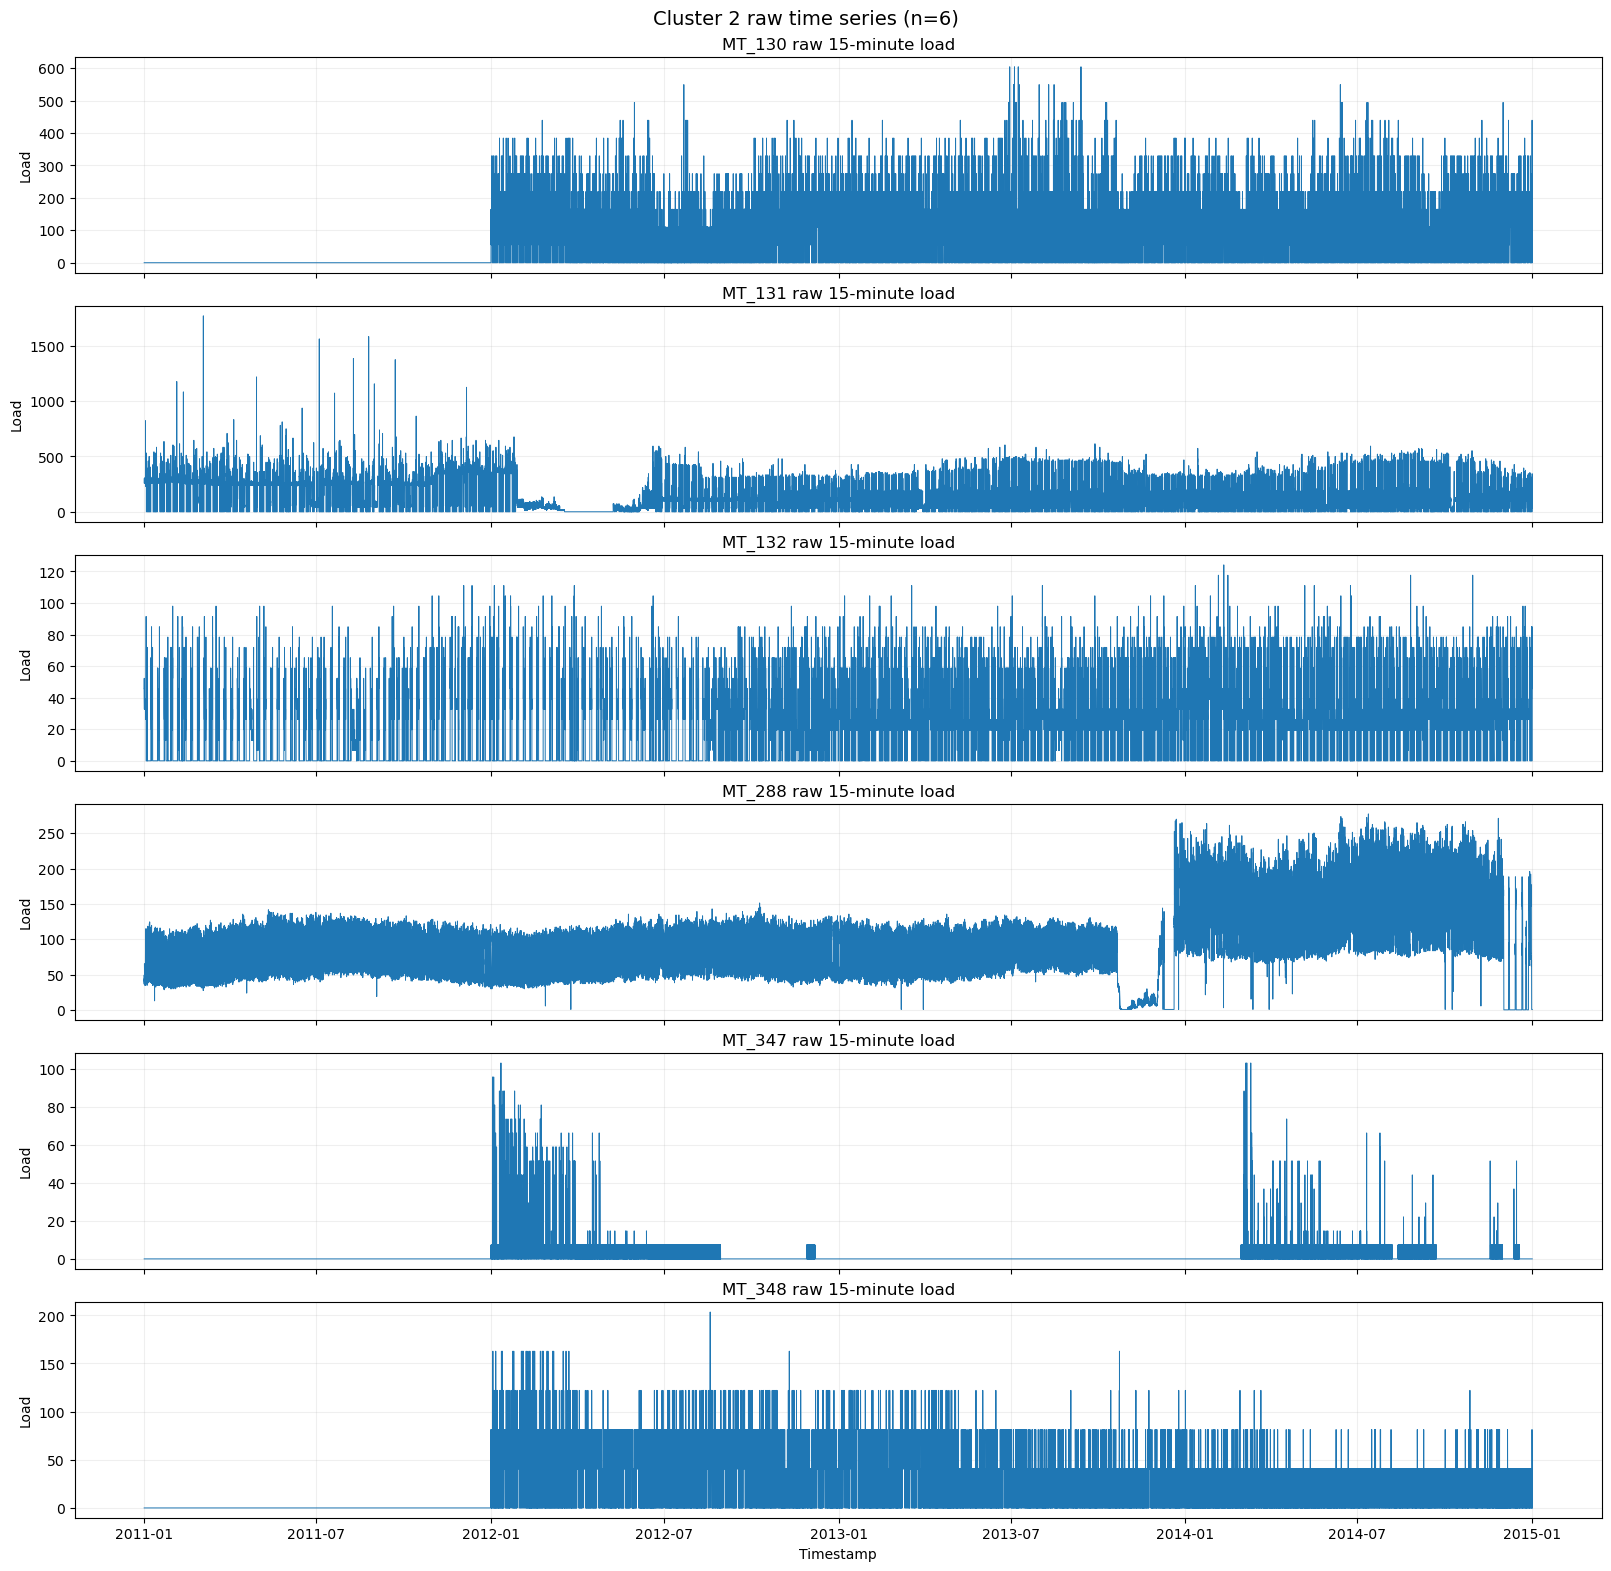

In [ ]:
raw_parquet_candidates = [
    preprocess_dir / "LD2011_2014_15min.parquet",
    preprocess_dir / "LD2011_2014.parquet",
]
raw_parquet_path = next((path for path in raw_parquet_candidates if path.exists()), None)
if raw_parquet_path is None:
    raise FileNotFoundError("Missing raw 15-minute parquet file.")
raw_15m_local = pd.read_parquet(raw_parquet_path).sort_index()
raw_15m_local.index = pd.to_datetime(raw_15m_local.index)
cluster_assignments = pd.read_parquet(out_dir / "clusters_3models.parquet")[["cluster_kmeans"]]["cluster_kmeans"].sort_index().astype(int)

target_cluster_id = 2
target_cluster_meters = cluster_assignments[cluster_assignments == target_cluster_id].index.tolist()
n_target_cluster_meters = len(target_cluster_meters)

if n_target_cluster_meters == 0:
    print(f"Cluster {target_cluster_id} has no meters in the current KMeans result.")
else:
    fig, axes = plt.subplots(
        n_target_cluster_meters,
        1,
        figsize=(16, 2.6 * n_target_cluster_meters),
        sharex=True,
        constrained_layout=True,
    )
    if n_target_cluster_meters == 1:
        axes = [axes]

    for ax, meter_id in zip(axes, target_cluster_meters):
        ax.plot(raw_15m_local.index, raw_15m_local[meter_id], linewidth=0.7)
        ax.set_title(f"{meter_id} raw 15-minute load")
        ax.set_ylabel("Load")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Timestamp")
    fig.suptitle(
        f"Cluster {target_cluster_id} raw time series (n={n_target_cluster_meters})",
        fontsize=14,
    )
    # save_svg(f"cluster_{target_cluster_id}_raw_timeseries")
    plt.show()


Saved: images\clustering\cluster_1_raw_timeseries.svg


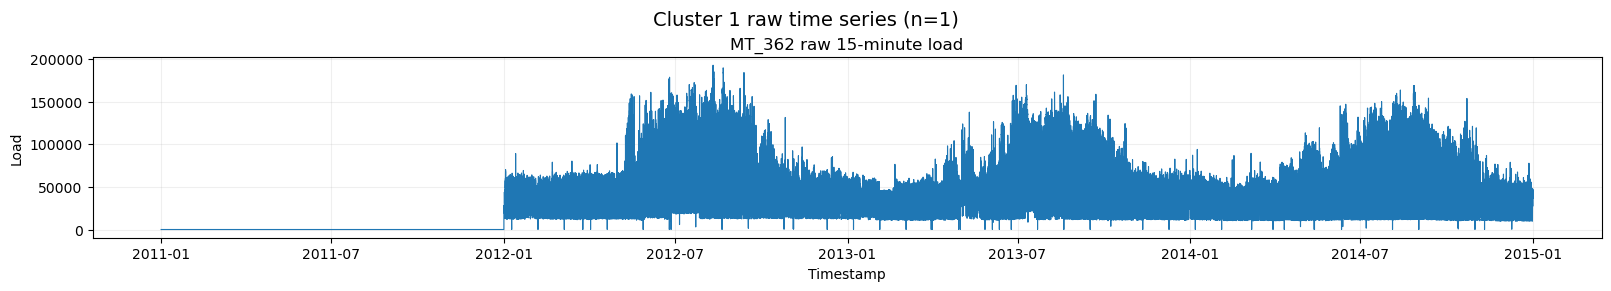

In [ ]:
raw_parquet_candidates = [
    preprocess_dir / "LD2011_2014_15min.parquet",
    preprocess_dir / "LD2011_2014.parquet",
]
raw_parquet_path = next((path for path in raw_parquet_candidates if path.exists()), None)
if raw_parquet_path is None:
    raise FileNotFoundError("Missing raw 15-minute parquet file.")
raw_15m_local = pd.read_parquet(raw_parquet_path).sort_index()
raw_15m_local.index = pd.to_datetime(raw_15m_local.index)
cluster_assignments = pd.read_parquet(out_dir / "clusters_3models.parquet")[["cluster_kmeans"]]["cluster_kmeans"].sort_index().astype(int)

target_cluster_id = 1
target_cluster_meters = cluster_assignments[cluster_assignments == target_cluster_id].index.tolist()
n_target_cluster_meters = len(target_cluster_meters)

if n_target_cluster_meters == 0:
    print(f"Cluster {target_cluster_id} has no meters in the current KMeans result.")
else:
    fig, axes = plt.subplots(
        n_target_cluster_meters,
        1,
        figsize=(16, 2.8 * n_target_cluster_meters),
        sharex=True,
        constrained_layout=True,
    )
    if n_target_cluster_meters == 1:
        axes = [axes]

    for ax, meter_id in zip(axes, target_cluster_meters):
        ax.plot(raw_15m_local.index, raw_15m_local[meter_id], linewidth=0.8)
        ax.set_title(f"{meter_id} raw 15-minute load")
        ax.set_ylabel("Load")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Timestamp")
    fig.suptitle(
        f"Cluster {target_cluster_id} raw time series (n={n_target_cluster_meters})",
        fontsize=14,
    )
    # save_svg(f"cluster_{target_cluster_id}_raw_timeseries")
    plt.show()


Saved: images\clustering\cluster_0_raw_timeseries_sample_5.svg


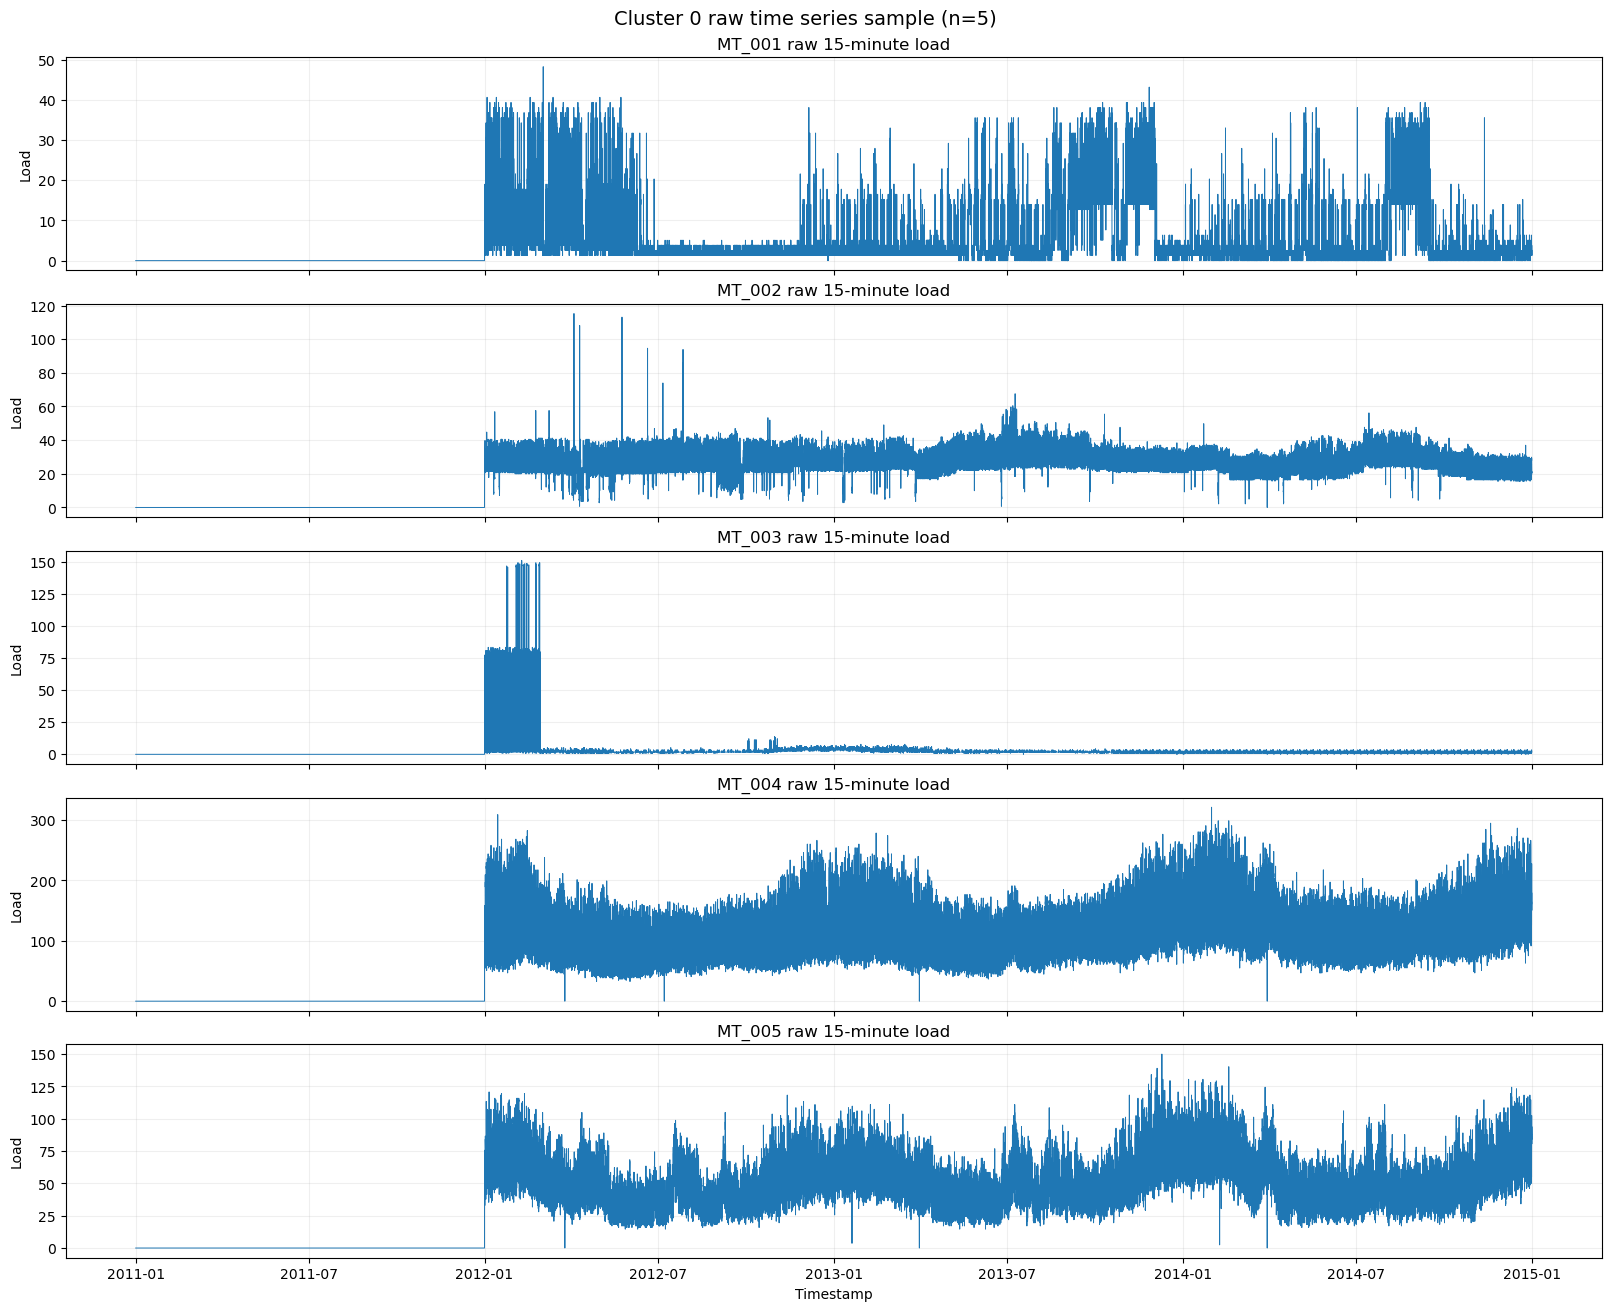

In [ ]:
raw_parquet_candidates = [
    preprocess_dir / "LD2011_2014_15min.parquet",
    preprocess_dir / "LD2011_2014.parquet",
]
raw_parquet_path = next((path for path in raw_parquet_candidates if path.exists()), None)
if raw_parquet_path is None:
    raise FileNotFoundError("Missing raw 15-minute parquet file.")
raw_15m_local = pd.read_parquet(raw_parquet_path).sort_index()
raw_15m_local.index = pd.to_datetime(raw_15m_local.index)
cluster_assignments = pd.read_parquet(out_dir / "clusters_3models.parquet")[["cluster_kmeans"]]["cluster_kmeans"].sort_index().astype(int)

sample_cluster_id = 0
sample_n = 5
sample_seed = 123
all_cluster_meters = cluster_assignments[cluster_assignments == sample_cluster_id].index.tolist()
rng = np.random.default_rng(sample_seed)
sample_size = min(sample_n, len(all_cluster_meters))
sample_cluster_meters = sorted(rng.choice(all_cluster_meters, size=sample_size, replace=False).tolist()) if sample_size > 0 else []
n_sample_cluster_meters = len(sample_cluster_meters)

if n_sample_cluster_meters == 0:
    print(f"Cluster {sample_cluster_id} has no meters in the current KMeans result.")
else:
    fig, axes = plt.subplots(
        n_sample_cluster_meters,
        1,
        figsize=(16, 2.6 * n_sample_cluster_meters),
        sharex=True,
        constrained_layout=True,
    )
    if n_sample_cluster_meters == 1:
        axes = [axes]

    for ax, meter_id in zip(axes, sample_cluster_meters):
        ax.plot(raw_15m_local.index, raw_15m_local[meter_id], linewidth=0.7)
        ax.set_title(f"{meter_id} raw 15-minute load")
        ax.set_ylabel("Load")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Timestamp")
    fig.suptitle(
        f"Cluster {sample_cluster_id} raw time series sample (n={n_sample_cluster_meters})",
        fontsize=14,
    )
    # save_svg(f"cluster_{sample_cluster_id}_raw_timeseries_sample_{n_sample_cluster_meters}")
    plt.show()
